<a href="https://colab.research.google.com/github/veronicaagunbiade-cmyk/CodeAlpha-Data-Science-Internship/blob/main/Car_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Car Price Prediction Using Machine Learning

Project Objective

The objective of this project is to build a machine learning model capable of predicting the selling price of used cars based on vehicle characteristics such as present price, mileage, fuel type, transmission type, ownership history, and vehicle age.

In [1]:
from google.colab import files

uploaded = files.upload()

Saving car data.csv to car data.csv


Import Libraries

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

Load Dataset

In [3]:
car_data = pd.read_csv('car data.csv')

car_data.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


Data Exploration

In [4]:
car_data.shape

(301, 9)

In [5]:
car_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [6]:
car_data.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [7]:
car_data.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Driven_kms,0
Fuel_Type,0
Selling_type,0
Transmission,0
Owner,0


## Feature Engineering

In [8]:
car_data['Car_Age'] = 2026 - car_data['Year']

In [9]:
car_data.drop(
    ['Car_Name','Year'],
    axis=1,
    inplace=True
)

In [10]:
car_data.head()

,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,4.75,9.54,43000,Diesel,Dealer,Manual,0,13
2,7.25,9.85,6900,Petrol,Dealer,Manual,0,9
3,2.85,4.15,5200,Petrol,Dealer,Manual,0,15
4,4.60,6.87,42450,Diesel,Dealer,Manual,0,12


## Exploratory Data Analysis (EDA)

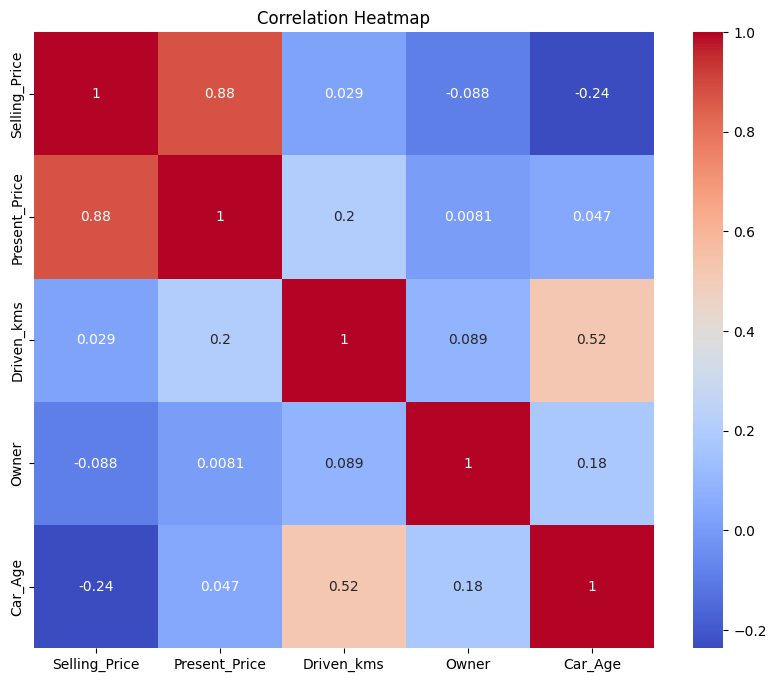

In [11]:
plt.figure(figsize=(10,8))

numeric_data = car_data.select_dtypes(include=['number'])

sns.heatmap(
    numeric_data.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

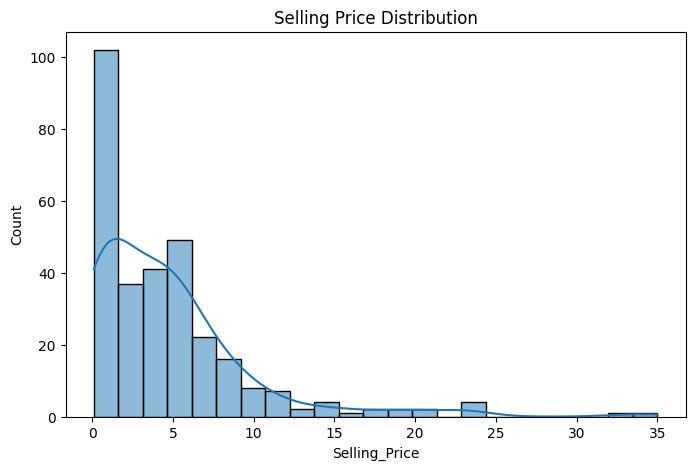

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(
    car_data['Selling_Price'],
    kde=True
)

plt.title('Selling Price Distribution')

plt.show()

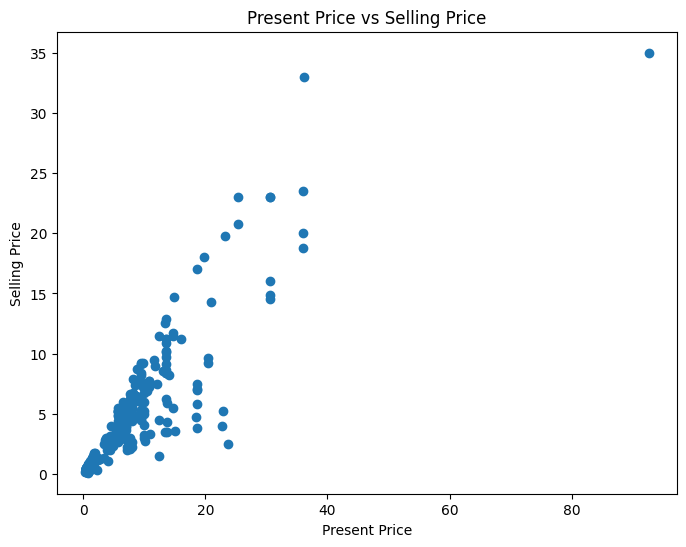

In [13]:
plt.figure(figsize=(8,6))

plt.scatter(
    car_data['Present_Price'],
    car_data['Selling_Price']
)

plt.xlabel('Present Price')

plt.ylabel('Selling Price')

plt.title('Present Price vs Selling Price')

plt.show()

## Data Preprocessing

In [14]:
car_data = pd.get_dummies(
    car_data,
    drop_first=True
)

In [15]:
car_data.head()

,Selling_Price,Present_Price,Driven_kms,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual
0,3.35,5.59,27000,0,12,False,True,False,True
1,4.75,9.54,43000,0,13,True,False,False,True
2,7.25,9.85,6900,0,9,False,True,False,True
3,2.85,4.15,5200,0,15,False,True,False,True
4,4.60,6.87,42450,0,12,True,False,False,True


## Model Training

In [16]:
X = car_data.drop(
    'Selling_Price',
    axis=1
)

y = car_data['Selling_Price']

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [18]:
lr_model = LinearRegression()

lr_model.fit(
    X_train,
    y_train
)

LinearRegression()

In [19]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

RandomForestRegressor(random_state=42)

## Model Evaluation

In [20]:
y_pred = rf_model.predict(X_test)

In [21]:
mae = mean_absolute_error(
    y_test,
    y_pred
)

mse = mean_squared_error(
    y_test,
    y_pred
)

r2 = r2_score(
    y_test,
    y_pred
)

print("MAE =", mae)
print("MSE =", mse)
print("R² =", r2)

MAE = 0.6368655737704919
MSE = 0.9339387986885236
R² = 0.9594566919773236


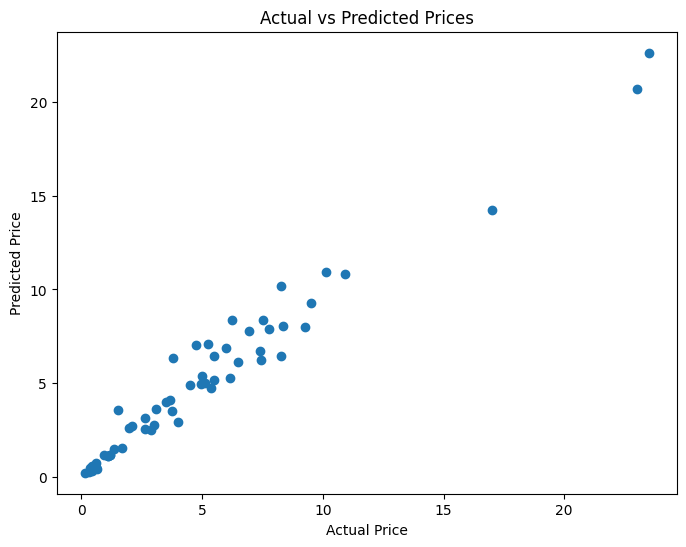

In [22]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Prices")

plt.show()

## Feature Importance Analysis

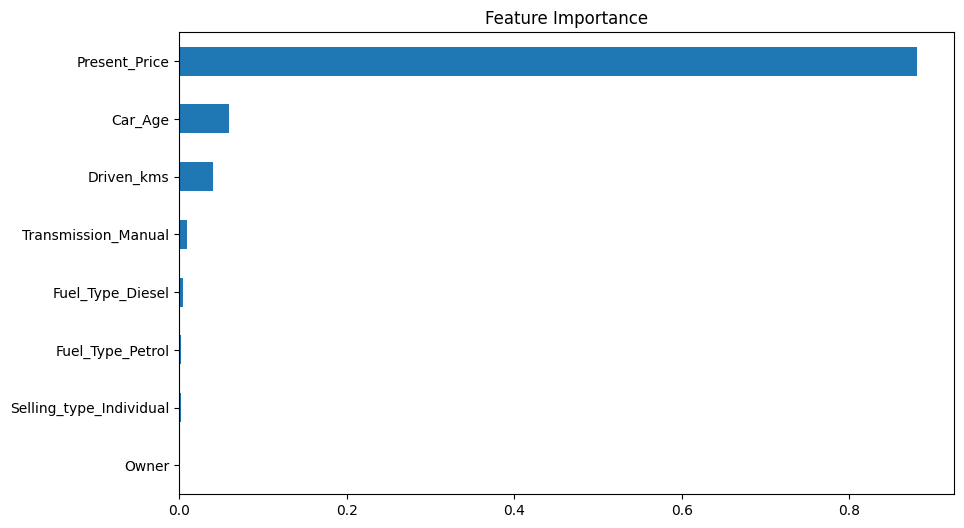

In [23]:
importance = rf_model.feature_importances_

features = X.columns

feature_importance = pd.Series(
    importance,
    index=features
)

feature_importance.sort_values().plot(
    kind='barh',
    figsize=(10,6)
)

plt.title("Feature Importance")

plt.show()

In [24]:
import joblib

joblib.dump(
    rf_model,
    'random_forest_model.pkl'
)

['random_forest_model.pkl']

In [25]:
from google.colab import files

files.download(
    'random_forest_model.pkl'
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Project Conclusion

This project developed a machine learning model to predict the selling price of used cars based on key vehicle characteristics such as present price, mileage, fuel type, transmission type, ownership history, and vehicle age.

The dataset was preprocessed through feature engineering and categorical variable encoding before being used to train machine learning models. A Random Forest Regressor was selected for prediction and achieved an R² score of 0.959, indicating excellent predictive performance. The model also recorded a Mean Absolute Error (MAE) of 0.637 and a Mean Squared Error (MSE) of 0.934, demonstrating strong accuracy in estimating vehicle resale prices.

Feature importance analysis revealed that Present Price, Car Age, and Driven Kilometers were the most influential factors affecting car resale value. The results show that machine learning can effectively capture pricing patterns and support data-driven decision-making in the automotive market.

This project successfully demonstrated the complete machine learning workflow, including data preprocessing, exploratory data analysis, model training, evaluation, and prediction.